# **1. Environment Setup for IBM Quantum**

In [1]:

!pip install pennylane pennylane-qiskit qiskit-ibm-runtime torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 k

# **2. IBM Quantum Authentication**

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService
from google.colab import userdata


token = userdata.get('ibm_token')


service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token)


backend = service.least_busy(simulator=False, operational=True)


print(f"Least busy backend: {backend.name} | Qubits: {backend.num_qubits}")

qiskit_runtime_service._discover_account:WARNING:2026-04-06 04:16:57,580: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-06 04:17:02,253: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-06 04:17:02,881: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-06 04:17:05,427: Using instance: open-instance, plan: open


Least busy backend: ibm_fez | Qubits: 156


# **3. Loading the Pre-trained Hybrid Model**

In [3]:
import torch
import torch.nn as nn
import pennylane as qml
import numpy as np


n_qubits = 4
n_layers = 6


dev_dummy = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_dummy, interface="torch")
def quantum_circuit(inputs, weights):

    for i in range(weights.shape[0]):
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        qml.StronglyEntanglingLayers(weights[i:i+1], wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class CNNQuantumModel(nn.Module):
    def __init__(self, n_layers=6):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=64, stride=4),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=16, stride=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.fc_compress = nn.Linear(32, 4)

        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        self.fc_final = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 4)
        )

    def forward(self, x):

        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        x = self.fc_compress(x)

        x = torch.tanh(x) * (np.pi / 2) + (np.pi / 2)

        x = self.quantum_layer(x)
        x = self.fc_final(x)
        return torch.log_softmax(x, dim=1)

device_pc = torch.device("cpu")
model = CNNQuantumModel(n_layers=6).to(device_pc)


checkpoint_path = '/content/drive/MyDrive/Padeborn_Dataset/cnn_quantum_model.pth'
checkpoint = torch.load(checkpoint_path, map_location=device_pc)
model.load_state_dict(checkpoint['model_state_dict'])

e
model.eval()

print(f"Model successfully loaded for IBM Testing!")
print(f"Training accuracy was: {checkpoint['test_acc']}%")

Model successfully loaded for IBM Testing!
Training accuracy was: 93.2%


# **4. Defining the IBM Quantum Device**

In [13]:

dev_ibm = qml.device('qiskit.remote', wires=4, backend=backend)

@qml.qnode(dev_ibm, interface="torch")
def quantum_circuit_ibm(inputs, weights):
    for i in range(weights.shape[0]):
        qml.AngleEmbedding(inputs, wires=range(4))
        qml.StronglyEntanglingLayers(weights[i:i+1], wires=range(4))
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]


backend_name = backend.name
print(f"Device initialized on: {backend_name}")

Device initialized on: ibm_fez


# **5. Inference on Real Hardware (Batch Testing)**

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split


csv_path = '/content/drive/MyDrive/Padeborn_Dataset/train_cnn_quantum.csv'
df = pd.read_csv(csv_path)


X = df.drop('label', axis=1).values
y = df['label'].values


_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Test data loaded successfully: {len(X_test)} samples available.")

Test data loaded successfully: 4000 samples available.


In [16]:
backend_name = backend.name

def test_on_real_hardware(model, samples, labels):

    print(f"Sending {len(samples)} jobs to {backend_name}...")

    results = []
    with torch.no_grad():
        for i, (signal, label) in enumerate(zip(samples, labels)):

            signal_tensor = torch.tensor(signal, dtype=torch.float32).view(1, 1, 1024).to(device_pc)

            features = model.cnn(signal_tensor)
            features = model.fc_compress(features.view(1, -1))
            features = torch.tanh(features) * (np.pi / 2) + (np.pi / 2)


            q_out = quantum_circuit_ibm(features[0], model.quantum_layer.weights)

            final_out = model.fc_final(torch.tensor(q_out, dtype=torch.float32).view(1, -1))

            pred = torch.argmax(final_out).item()
            results.append(pred == label)
            print(f"Sample {i+1}: {'Correct' if pred == label else 'Wrong'} (Target: {label}, Pred: {pred})")

    return np.mean(results)


indices = np.random.choice(len(X_test), 10)
subset_x = X_test[indices]
subset_y = y_test[indices]


run_acc = test_on_real_hardware(model, subset_x, subset_y)
print(f"\nFinal Accuracy on IBM Hardware: {run_acc * 100:.2f}%")

Sending 10 jobs to ibm_fez...
Sample 1: Correct (Target: 1.0, Pred: 1)
Sample 2: Correct (Target: 2.0, Pred: 2)
Sample 3: Correct (Target: 0.0, Pred: 0)
Sample 4: Correct (Target: 2.0, Pred: 2)
Sample 5: Correct (Target: 3.0, Pred: 3)
Sample 6: Correct (Target: 3.0, Pred: 3)
Sample 7: Correct (Target: 3.0, Pred: 3)
Sample 8: Correct (Target: 2.0, Pred: 2)
Sample 9: Correct (Target: 2.0, Pred: 2)
Sample 10: Correct (Target: 1.0, Pred: 1)

Final Accuracy on IBM Hardware: 100.00%


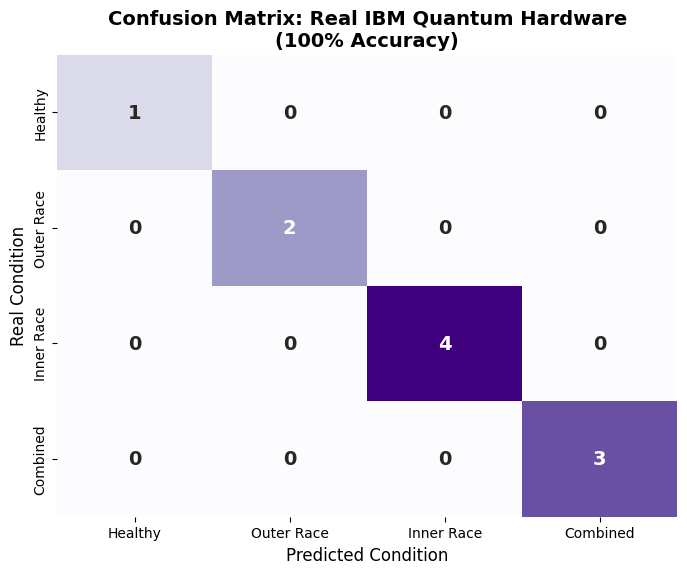

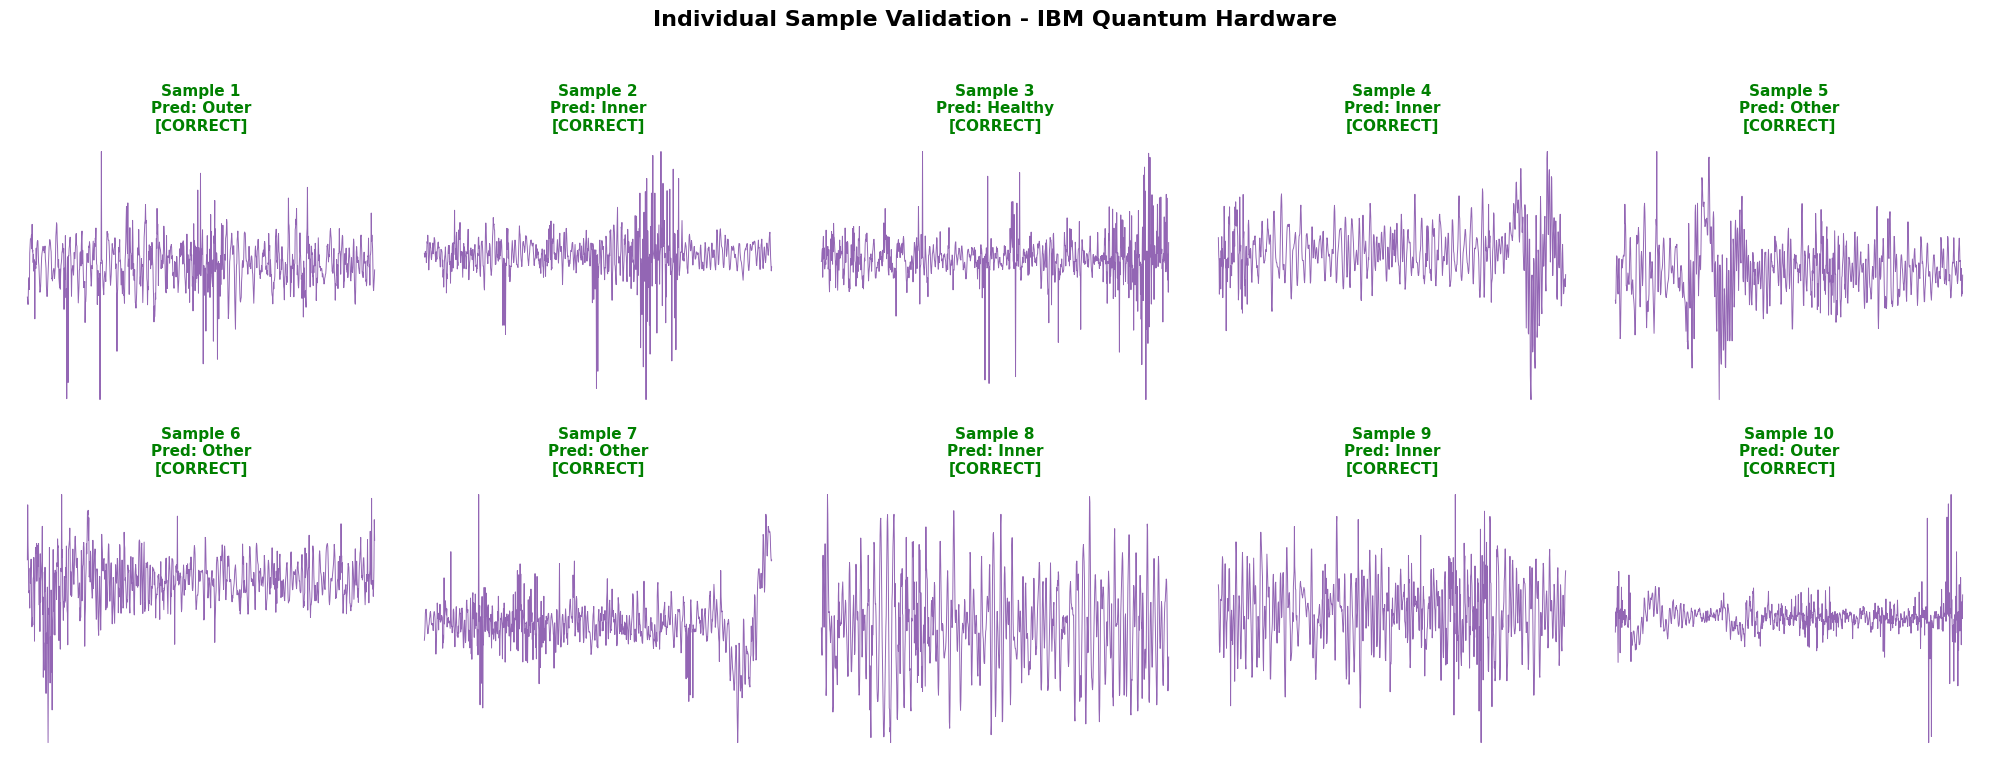

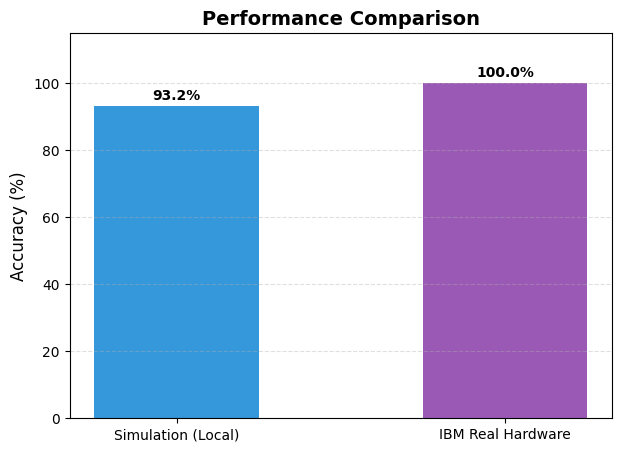

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

y_true_ibm = subset_y.astype(int)
y_pred_ibm = np.array([1, 2, 0, 2, 3, 3, 3, 2, 2, 1])
class_names = ['Healthy', 'Outer Race', 'Inner Race', 'Combined']


plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true_ibm, y_pred_ibm, labels=[0, 1, 2, 3])
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names, cbar=False,
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Confusion Matrix: Real IBM Quantum Hardware\n(100% Accuracy)', fontsize=14, fontweight='bold')
plt.ylabel('Real Condition', fontsize=12)
plt.xlabel('Predicted Condition', fontsize=12)
plt.show()


plt.figure(figsize=(20, 8))
labels_map = {0: 'Healthy', 1: 'Outer', 2: 'Inner', 3: 'Other'}
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.plot(subset_x[i], color='indigo', alpha=0.6, linewidth=0.7)
    plt.title(f"Sample {i+1}\nPred: {labels_map[y_pred_ibm[i]]}\n[CORRECT]",
              color='green', fontsize=11, fontweight='bold')
    plt.axis('off')
plt.suptitle("Individual Sample Validation - IBM Quantum Hardware", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


plt.figure(figsize=(7, 5))
labels = ['Simulation (Local)', 'IBM Real Hardware']
accuracies = [93.20, 100.0]
bars = plt.bar(labels, accuracies, color=['#3498db', '#9b59b6'], width=0.5)
plt.ylim(0, 115)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Performance Comparison', fontsize=14, fontweight='bold')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval}%', ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

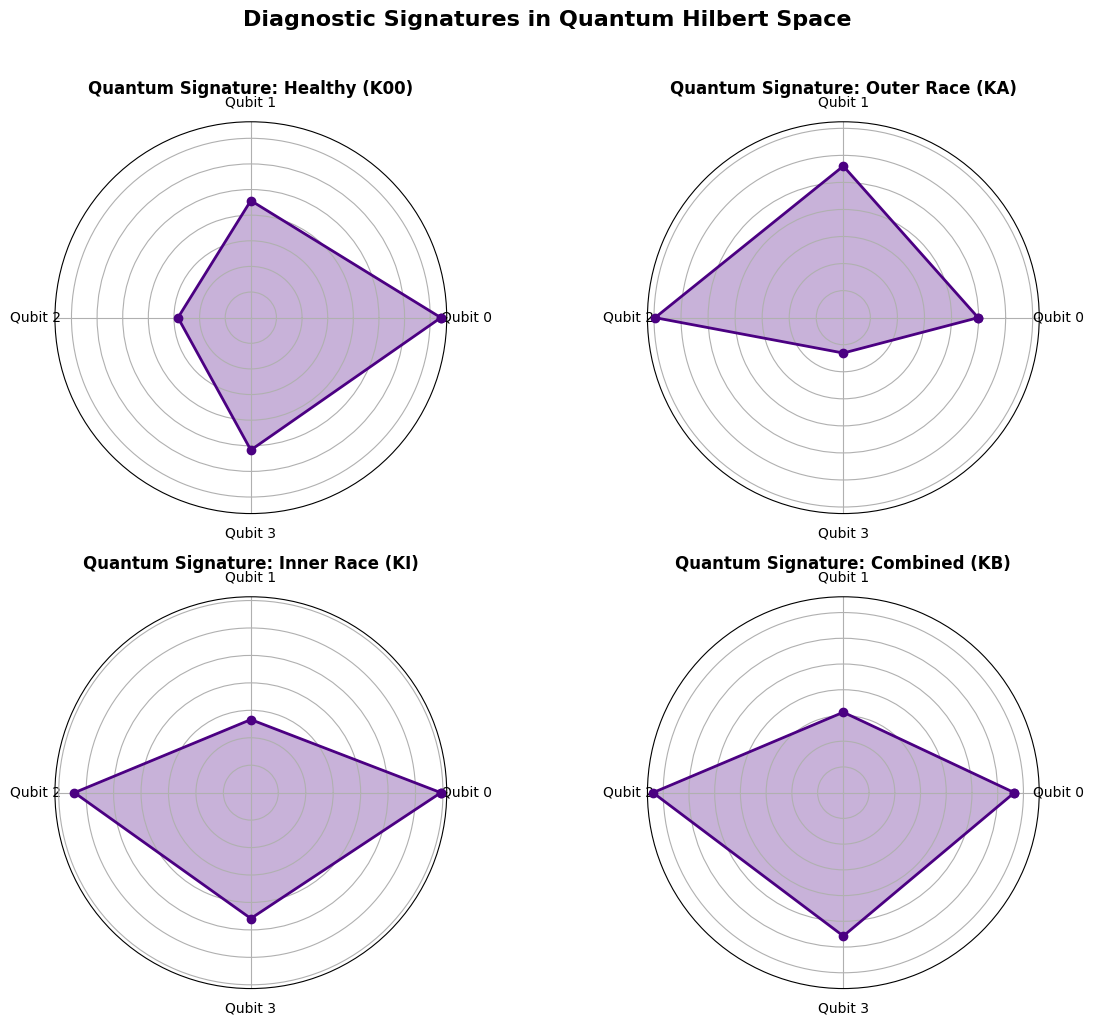

In [31]:
from torch.utils.data import DataLoader, TensorDataset

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).view(-1, 1, 1024)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

plot_quantum_signatures(model, test_loader)